# Homework 3

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = False


def top_k(score_dict, k=5):
    return sorted(score_dict.items(), key=lambda x: x[1], reverse=True)[:k]


def similarity_pairs(sim_df, k=10):
    pairs = []
    nodes = list(sim_df.index)
    for i, u in enumerate(nodes):
        for j in range(i + 1, len(nodes)):
            v = nodes[j]
            pairs.append((u, v, float(sim_df.loc[u, v])))
    pairs.sort(key=lambda x: x[2], reverse=True)
    return pairs[:k]


def plot_graph_with_labels(G, title, node_values=None):
    pos = nx.kamada_kawai_layout(G)
    plt.figure(figsize=(11, 7))

    if node_values is None:
        node_values = {n: 1.0 for n in G.nodes()}

    values = np.array([node_values[n] for n in G.nodes()])
    sizes = 500 + 2500 * values / values.max()
    nodes = nx.draw_networkx_nodes(
        G,
        pos,
        node_size=sizes,
        node_color=values,
        cmap="viridis",
    )

    widths = []
    for _, _, data in G.edges(data=True):
        widths.append(0.5 + data.get("weight", 1.0) * 0.15)

    nx.draw_networkx_edges(G, pos, width=widths, alpha=0.35)
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.colorbar(nodes, label="Node value")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def plot_similarity_heatmap(sim_df, title):
    plt.figure(figsize=(10, 8))
    plt.imshow(sim_df.values, cmap="magma", vmin=0, vmax=1)
    plt.colorbar(label="SimRank similarity")
    plt.xticks(range(len(sim_df.columns)), sim_df.columns, rotation=90)
    plt.yticks(range(len(sim_df.index)), sim_df.index)
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_pair_neighborhood(G, u, v):
    neigh_u = set(G.neighbors(u))
    neigh_v = set(G.neighbors(v))
    nodes = {u, v} | neigh_u | neigh_v
    H = G.subgraph(nodes).copy()

    common = neigh_u & neigh_v
    only_u = neigh_u - neigh_v
    only_v = neigh_v - neigh_u

    colors = []
    sizes = []
    for n in H.nodes():
        if n in {u, v}:
            colors.append("crimson")
            sizes.append(1800)
        elif n in common:
            colors.append("orange")
            sizes.append(900)
        elif n in only_u:
            colors.append("skyblue")
            sizes.append(700)
        elif n in only_v:
            colors.append("lightgreen")
            sizes.append(700)
        else:
            colors.append("lightgray")
            sizes.append(600)

    pos = nx.kamada_kawai_layout(H)
    plt.figure(figsize=(8, 6))
    nx.draw(H, pos, with_labels=True, node_color=colors, node_size=sizes, width=1.5)
    plt.title(f"1-step neighborhoods of {u} and {v}")
    plt.tight_layout()
    plt.show()

    print(f"Common neighbors of {u} and {v}: {sorted(common)}")
    print(f"Neighbors only of {u}: {sorted(only_u)}")
    print(f"Neighbors only of {v}: {sorted(only_v)}")

## 1. Select a dense labeled graph

Full graph: 77 nodes, 254 edges
Selected subgraph: 24 nodes, 88 edges
Density of selected undirected subgraph: 0.319

Selected nodes (top 24 by PageRank):
  Valjean              0.0996
  Marius               0.0517
  Myriel               0.0393
  Cosette              0.0369
  Enjolras             0.0366
  Thenardier           0.0357
  Courfeyrac           0.0330
  Gavroche             0.0283
  Fantine              0.0272
  Javert               0.0268
  Combeferre           0.0266
  Bossuet              0.0262
  MmeThenardier        0.0200
  MmeMagloire          0.0195
  Gillenormand         0.0183
  Joly                 0.0177
  MlleBaptistine       0.0174
  MlleGillenormand     0.0167
  Bahorel              0.0164
  Babet                0.0157
  Feuilly              0.0155
  Gueulemer            0.0147
  Favourite            0.0141
  Tholomyes            0.0141


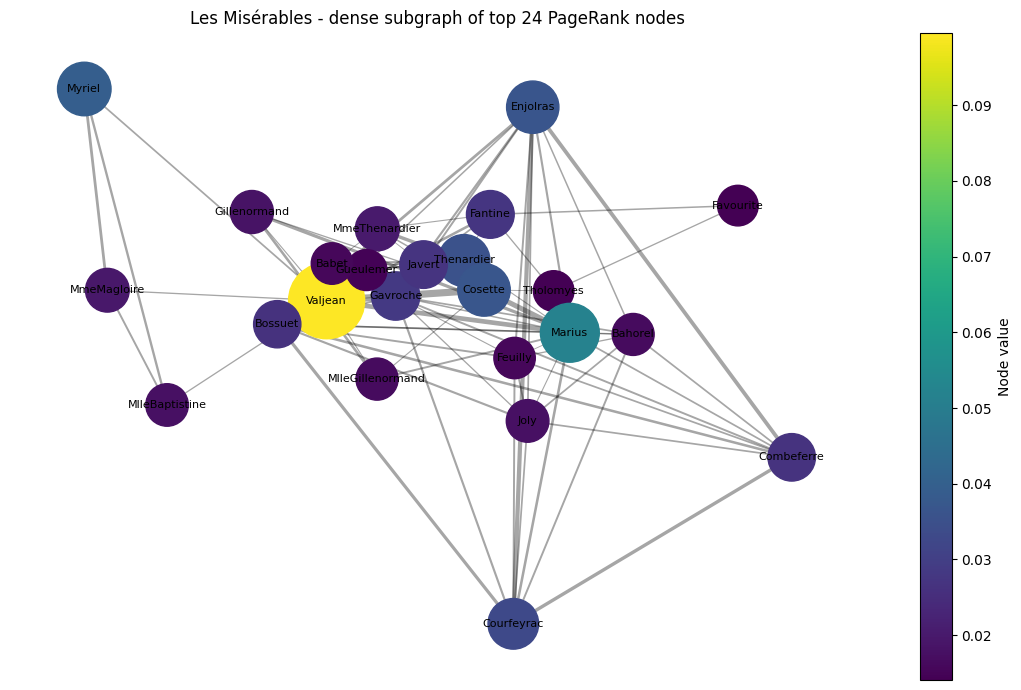

In [2]:
G = nx.les_miserables_graph()

pr = nx.pagerank(G, alpha=0.85, weight="weight")
selected_nodes = [n for n, _ in top_k(pr, k=24)]
H = G.subgraph(selected_nodes).copy()
D = H.to_directed()

print(f"Full graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Selected subgraph: {H.number_of_nodes()} nodes, {H.number_of_edges()} edges")
print(f"Density of selected undirected subgraph: {nx.density(H):.3f}")
print("\nSelected nodes (top 24 by PageRank):")
for n, score in top_k({n: pr[n] for n in selected_nodes}, k=24):
    print(f"  {n:20s} {score:.4f}")

plot_graph_with_labels(H, "Les Misérables - dense subgraph of top 24 PageRank nodes",
                       node_values={n: pr[n] for n in H.nodes()})

## 2. Compute SimRank step by step

In [3]:
def simrank_iterations(G, C=0.8, iterations=8):
    nodes = list(G.nodes())
    idx = {node: i for i, node in enumerate(nodes)}

    S = np.eye(len(nodes), dtype=float)
    history = [S.copy()]

    for _ in range(iterations):
        new_S = np.eye(len(nodes), dtype=float)
        for i, u in enumerate(nodes):
            in_u = list(G.predecessors(u))
            for j, v in enumerate(nodes):
                if i == j:
                    continue
                in_v = list(G.predecessors(v))
                if len(in_u) == 0 or len(in_v) == 0:
                    new_S[i, j] = 0.0
                else:
                    total = 0.0
                    for a in in_u:
                        for b in in_v:
                            total += S[idx[a], idx[b]]
                    new_S[i, j] = C * total / (len(in_u) * len(in_v))
        S = new_S
        history.append(S.copy())

    return nodes, history


def history_to_df(nodes, matrix):
    return pd.DataFrame(matrix, index=nodes, columns=nodes)


def tracked_pair_history(nodes, history, pairs):
    rows = []
    idx = {node: i for i, node in enumerate(nodes)}
    for t, mat in enumerate(history):
        row = {f"{u} - {v}": float(mat[idx[u], idx[v]]) for u, v, _ in pairs}
        row["iteration"] = t
        rows.append(row)
    return pd.DataFrame(rows).set_index("iteration")

Top 10 most similar distinct pairs by SimRank:
  MmeMagloire     MlleBaptistine  0.3077
  Myriel          MmeMagloire     0.3077
  Myriel          MlleBaptistine  0.3077
  Gillenormand    MlleGillenormand 0.2457
  Gueulemer       Babet           0.2181
  Feuilly         Bahorel         0.2172
  Courfeyrac      Bahorel         0.2172
  Joly            Bahorel         0.2172
  Combeferre      Bahorel         0.2172
  Feuilly         Courfeyrac      0.2172

Similarity values over iterations for the top 5 pairs:


,MmeMagloire - MlleBaptistine,Myriel - MmeMagloire,Myriel - MlleBaptistine,Gillenormand - MlleGillenormand,Gueulemer - Babet
iteration,,,,,
0,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.1778,0.1778,0.1778,0.1500,0.1111
2,0.2370,0.2370,0.2370,0.1829,0.1491
3,0.2661,0.2661,0.2661,0.2030,0.1722
4,0.2818,0.2818,0.2818,0.2168,0.1876
5,0.2918,0.2918,0.2918,0.2272,0.1988
6,0.2988,0.2988,0.2988,0.2351,0.2071
7,0.3038,0.3038,0.3038,0.2411,0.2134
8,0.3077,0.3077,0.3077,0.2457,0.2181


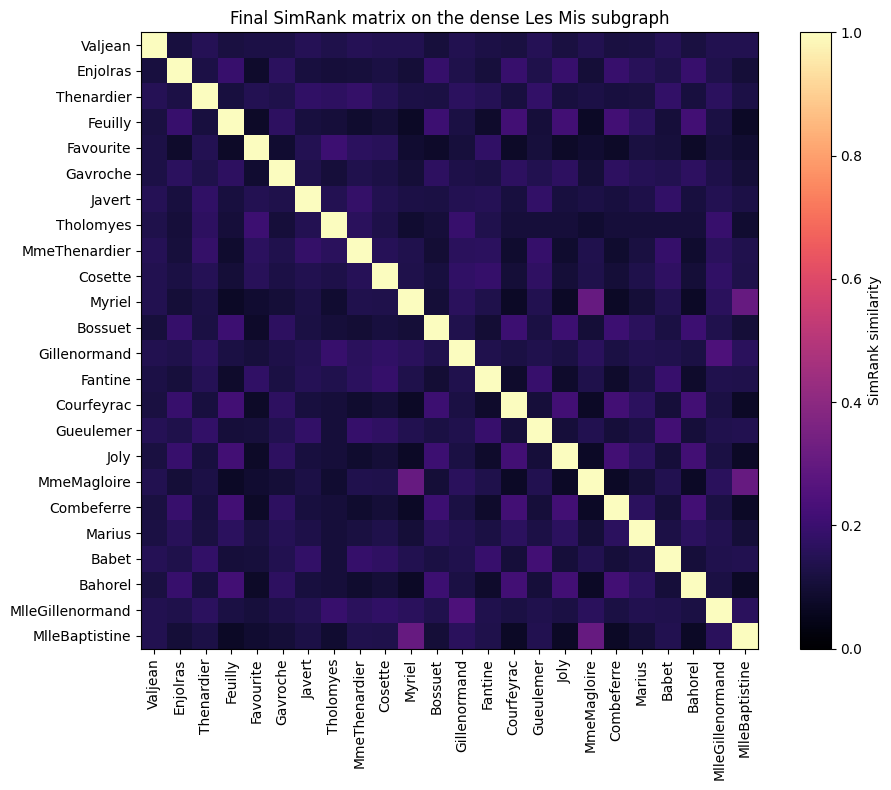

In [4]:
nodes, history = simrank_iterations(D, C=0.8, iterations=8)
sim_df = history_to_df(nodes, history[-1])

print("Top 10 most similar distinct pairs by SimRank:")
top_pairs = similarity_pairs(sim_df, k=10)
for u, v, s in top_pairs:
    print(f"  {u:15s} {v:15s} {s:.4f}")

tracked = tracked_pair_history(nodes, history, top_pairs[:5])
print("\nSimilarity values over iterations for the top 5 pairs:")
display(tracked.round(4))

plot_similarity_heatmap(sim_df, "Final SimRank matrix on the dense Les Mis subgraph")

## 3. Explanation of similarity by 1-step neighborhoods


Pair: MmeMagloire - MlleBaptistine | SimRank = 0.3077
Number of common neighbors: 2
Most important common neighbors:
  Valjean              PageRank=0.0996
  Myriel               PageRank=0.0393


/var/folders/c0/cwrxt68d6x5gt7cy51ww7z9r0000gn/T/ipykernel_543/3661861832.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


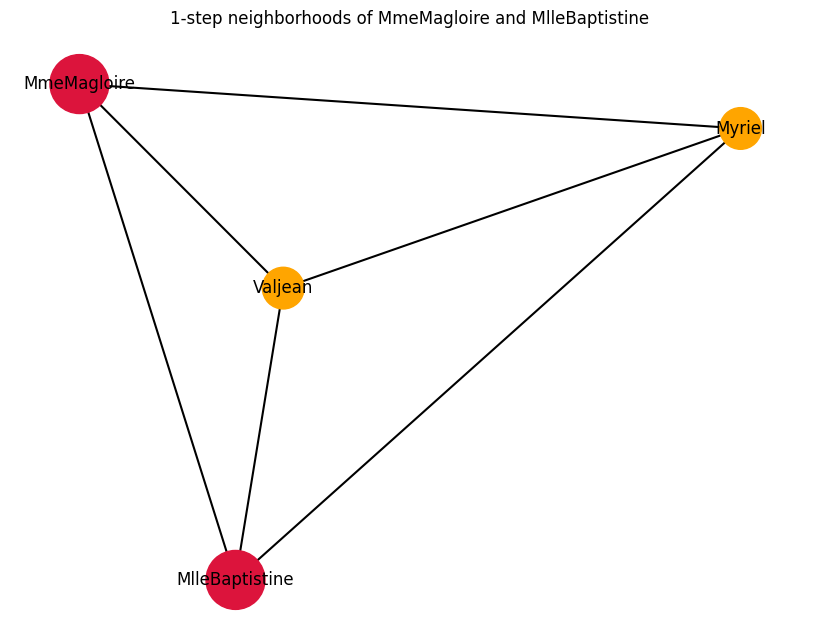

Common neighbors of MmeMagloire and MlleBaptistine: ['Myriel', 'Valjean']
Neighbors only of MmeMagloire: ['MlleBaptistine']
Neighbors only of MlleBaptistine: ['MmeMagloire']

Pair: Myriel - MmeMagloire | SimRank = 0.3077
Number of common neighbors: 2
Most important common neighbors:
  Valjean              PageRank=0.0996
  MlleBaptistine       PageRank=0.0174


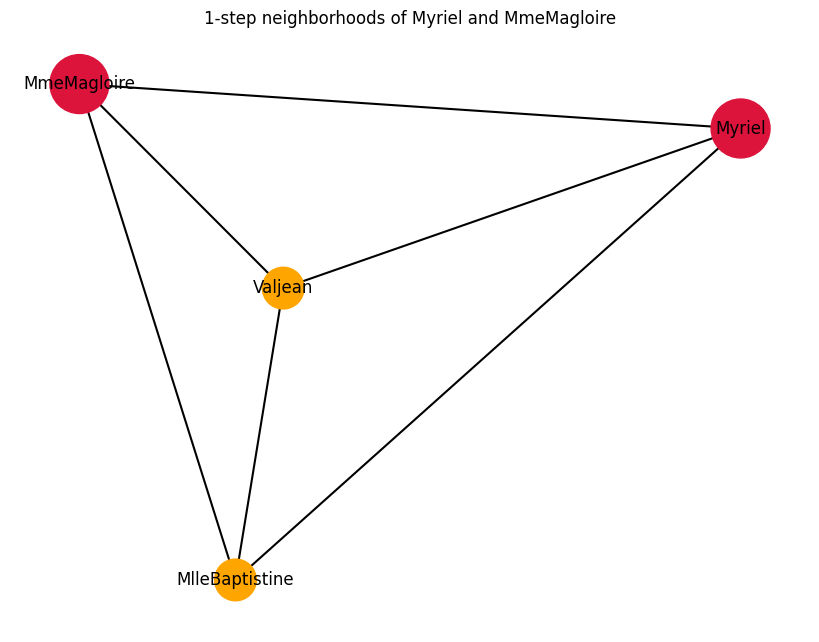

Common neighbors of Myriel and MmeMagloire: ['MlleBaptistine', 'Valjean']
Neighbors only of Myriel: ['MmeMagloire']
Neighbors only of MmeMagloire: ['Myriel']

Pair: Myriel - MlleBaptistine | SimRank = 0.3077
Number of common neighbors: 2
Most important common neighbors:
  Valjean              PageRank=0.0996
  MmeMagloire          PageRank=0.0195


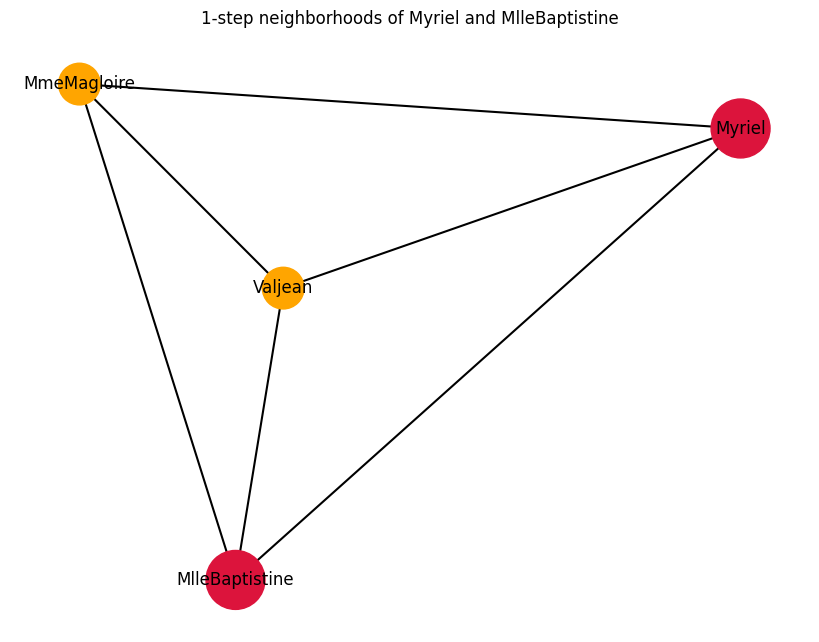

Common neighbors of Myriel and MlleBaptistine: ['MmeMagloire', 'Valjean']
Neighbors only of Myriel: ['MlleBaptistine']
Neighbors only of MlleBaptistine: ['Myriel']


In [5]:
selected_pairs = top_pairs[:3]

for u, v, s in selected_pairs:
    print(f"\nPair: {u} - {v} | SimRank = {s:.4f}")
    common = set(H.neighbors(u)) & set(H.neighbors(v))
    print(f"Number of common neighbors: {len(common)}")
    if common:
        common_scores = sorted([(n, pr[n]) for n in common], key=lambda x: x[1], reverse=True)
        print("Most important common neighbors:")
        for n, score in common_scores[:8]:
            print(f"  {n:20s} PageRank={score:.4f}")
    plot_pair_neighborhood(H, u, v)